# Training a regressor to discover efficient enzymes with `evedesign`

In the last case study of the `evedesign` preprint, we reproduced the workflow from [Eom *et al.*](https://academic.oup.com/nar/article/53/1/gkae1245/7944727) for discovering more efficient kynureninases (KYNases) using a supervised model based on protein language model embeddings.

In this notebook we will show how `evedesign` enables training a Random Forest model using ESM-2 as the embedder to predict enzyme kinetics, which achieves similar performance to that shown in Eom *et al.* We will also show how homologs can be scored using the `score()` function, which enables the identification of more efficient variants. In particular, we will check the score of KYNase variants that were experimentally tested in the original study, and show that a superior variant is highly-ranked, whereas a less-efficient variant has a low rank.

In [1]:
# set random seed
import torch
import pandas as pd
import numpy as np
from evedesign.system import System, Protein
from evedesign.models.esm2 import ESM2
from evedesign import dataset
from evedesign.models import supervised
from evedesign.system import SystemInstance, EntityInstance
from evedesign.sequence import read_fasta

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

/Users/thomashopf/mambaforge/envs/modal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Obtain training data

In order to train the model, we'll be using the training data from the original study. The underlying file (`seekrank_training_seqs.fasta`) was directly downloaded from [zenodo](https://zenodo.org/records/10517668) (the original study).

In [2]:
training_df = pd.read_csv(f"training_data.csv")
training_df.head()

,name,kcat/km,seq
0,Pf-KYNU|Pf-KYNU|76000,76000.0,MTSRSHCQTLDAQDPLAPLRDQFALPAGVIYLDGNSLGARPVASLA...
1,Mp-KYNU|Mp-KYNU|57000,57000.0,MNYQNTLAFARELDEQDNLAGFRNEFIIPQHHGRDMIYLCGNSLGL...
2,Ab-KYNU|Ab-KYNU|54000,54000.0,MITREQCLYWDQEDELKKFKDEFALPEGVIYLDGNSLGARPKKSLA...
3,Mm-KYNU|Mm-KYNU|520,520.0,MEPSPLELPVDAVRRIAAELNCDPTDERVALRLDEEDKLSHFRNCF...
4,Cp-KYNU|Cp-KYNU|27000,27000.0,MIEKLKQYHDEAISLDSLDPLQKFKECFTLPKEPGALYFCSNSLGL...


The reference sequence used in the original study is the KYNase from *Pseudomonas fluorescens* (Pf-K). 

In [3]:
# We can get the reference Pf-K sequence from the first entry of the training set
pfk_seq = training_df.iloc[0]["seq"]
pfk_seq

'MTSRSHCQTLDAQDPLAPLRDQFALPAGVIYLDGNSLGARPVASLARAQQVIAEEWGNGLIRSWNSAGWADLSLRLGNRLAPLIGAGAGEVAITDTTSINLFKVLSAALTVQRQREPARKVIVSEASNFPTDLYIAEGLAELLQQGYCLRLVNSPDELPQAIDADVAVVMLTHVNYKTGYMYDMQALTALSHECGALSIWDLAHSAGAVPIDLRAAGADYAIGCTYKYLNGGPGSQAFVWVNPALVDQVRQPLSGWFGHTRQFAMESNYAPSAGIARYLCGTQPITSLAMVECGLQIFEQTDMACLRRKSLALTDLFIALVEARCAAHGLVLITPREHARRGSHVSFEHPEGYAVIQALIARGVIGDYREPRIMRFGFTPLYTRFSEVWDAVEILGEILDESTWDQPQFKVRHSVT'

## 2. Define system and build embedder

In this case, a simple one-protein system is sufficient to build the ESM-2 model to be used as the embedder.

In [4]:
system = System(
    Protein(
        id="Pf-K", rep=pfk_seq, first_index=1, sequences=None, structures=None
    )
)

esm_model = ESM2(
    model_name="esm2_t33_650M_UR50D",  # 650M parameter model
    batch_size=16,
    device=DEVICE,
)

esm_model.build(system);

## 3. Train Random Forest model

We will simply define training instances using our training set dataframe `df`, with corresponding `kcat/km` labels.

In [5]:
instances = [
    SystemInstance(EntityInstance(rep=seq))
    for seq in training_df["seq"]
]

dataset = dataset.LabeledInstanceDataset(
    instances=instances,
    labels={
        "kcat/km": training_df['kcat/km'].tolist()
    },
    splits=("cv", 5)  # noqa
)

The supervised model (a Random Forest) will be trained with 5-fold cross-validation. Any `scikit-learn` predictor can be used. Model scores are also used as features in this case.

In [6]:
SEED = 42
p = supervised.SklearnPredictorOnEmbeddingsScores(
    use_scores=True,
    use_embeddings=True,
    embedder=esm_model,
    pooling="mean",
    predictor="RandomForestRegressor",
    predictor_kwargs={'random_state': SEED},
).build(system, data=dataset)

Some weights of the model checkpoint at facebook/esm2_t33_650M_UR50D were not used when initializing EsmForMaskedLM: ['esm.embeddings.position_embeddings.weight']
- This IS expected if you are initializing EsmForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


We can now check cross-validation performance:

In [7]:
model_stats = p.stats()

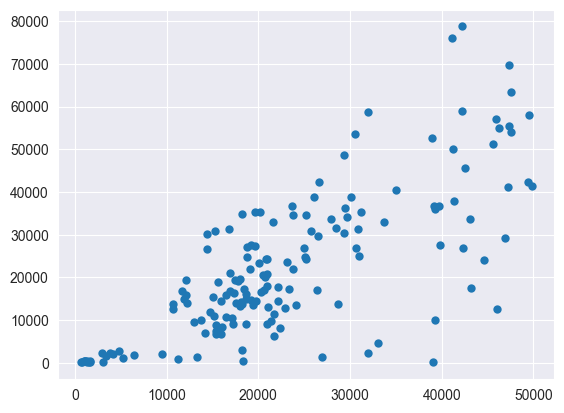

In [8]:
try:
    import seaborn as sns
    sns.scatterplot(
         x=np.concatenate(model_stats["y_pred"]), y=np.concatenate(model_stats["y_true"]), lw=0
    )
except ImportError:
    print("Install seaborn for this visualization")

In [9]:
np.array(model_stats["scores"]["spearman"]).mean()

0.7267688162972032

We can see that performance is similar to that from the original study using ESM-2 (Spearman $\rho$=0.72 in Eom *et al.*).

## 4. Predict the catalytic efficiency of homologs with `score()`

Importantly, the supervised model can be used to predict the catalytic efficiencies of KYNase homologs for discovery. The list of homologs from Eom *et al.* can also be obtained from [zenodo](https://zenodo.org/records/10517668) (`nonredundant_target_sequences.fasta`). First, homolog sequences are used to define homolog instances for scoring.

To make this execute quicker, we only score the first 100 sequences here

In [10]:
NUM_SEQS = 100

In [11]:
# Read homolog sequences fasta and extract sequences
with open("nonredundant_target_sequences.fasta") as f:
    seqs = [
        seq for (header, seq) in read_fasta(f)
    ]

# Filter sequences that are too long for ESM-2 (max is 1022)
seqs_filtered = [
    seq for seq in seqs if len(seq) <= 1022
][:NUM_SEQS]

# Create system instances
homolog_instances = [
    SystemInstance(EntityInstance(rep=seq))
    for seq in seqs_filtered
]

We can now simply predict catalytic efficiencies using `score()`.

In [12]:
homolog_instances_scored = p.score(homolog_instances)

In [13]:
# Create dataframe with sequences and their scores
df_homologs = pd.DataFrame({
    'sequence': seqs_filtered,
    'score': [inst.score for inst in homolog_instances_scored],
    'length': [len(seq) for seq in seqs_filtered]
})
df_homologs['normalized_max_score'] = df_homologs['score'] / df_homologs['score'].max()

# Sort by score
df_homologs = df_homologs.sort_values('score', ascending=False).reset_index(drop=True)
df_homologs

,sequence,score,length,normalized_max_score
0,MIDKNHCLRLDEQDPLAPLRQQFALPEGVIYLDGNSLGARPVASLE...,63507.038333,416,1.000000
1,MTTRNDCLTLDAQDALAPLRQQFALPEGVIYLDGNSLGARPVAALA...,63230.088333,416,0.995639
2,MTTRNDCLALDAQDTLAPLRDQFALPEGVIYLDGNSLGARPKASLE...,62647.943333,416,0.986472
3,MTTRNHCLALDAQDPLAPLRDQFALPEGVIYLDGNSLGARPVASLQ...,62460.198333,416,0.983516
4,MLTRADCLAADARDPLASFKEQFNIPQGVIYLDGNSLGAQPKASMS...,62293.555000,416,0.980892
...,...,...,...,...
95,MTTREDCLALDARDPLGPLREEFVLPEGVIYLDGNSLGARPRPALQ...,49902.756667,416,0.785783
96,MKRGFATLPLPHDTLSLKQYHAILISLNMKATTMISQHDCRARDLD...,49164.874033,449,0.774164
97,MTIAETLSPEALAAAPTREACAAADAADPLARFRSAFVLPEGVVYL...,48827.467367,430,0.768851
98,MTAPILTRADCLARDALDPLAGLRTRFDLPDGVIYLDGNSLGARPR...,48131.074033,424,0.757886


## References

Eom H, Park S, Cho KS, et al. Discovery of highly active kynureninases for cancer immunotherapy through protein language model. Nucleic Acids Res. 2025;53(1):gkae1245. 

https://doi.org/10.1093/nar/gkae1245